## Color Quantization with k‑Means (scikit‑learn)


In [3]:
import numpy as np, matplotlib.pyplot as plt, os, requests, io
from sklearn.cluster import KMeans
from PIL import Image

Loaded image: (128, 183, 3)


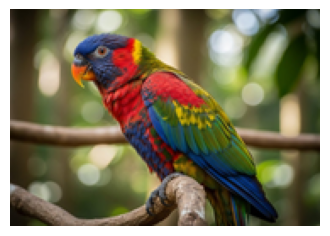

In [4]:
# Load an image ----------------------------------------------------------
IMAGE_URL = 'https://search.pstatic.net/common/?src=http%3A%2F%2Fblogfiles.naver.net%2FMjAyNjAxMjJfNTQg%2FMDAxNzY5MDUzMTU2MDg3.Qp_mFUOmSwfT5s2Ts9KLmLsBY5Kd4gwfDhanu-Ns4uEg.2WX7BIKEXeABk4nDpec_7XqHxSmKbgFmJRFJ3aYPqm0g.JPEG%2F%25BE%25DE%25B9%25AB%25BB%25F5_%25281%2529.jpg&type=sc960_832'
# requests.get()을 사용해 해당 URL에서 이미지 데이터를 가져온다.
# timeout=10은 요청이 10초 이상 걸리면 중단하겠다는 의미이다
response = requests.get(IMAGE_URL, timeout=10)


# HTTP 요청이 실패했는지 확인한다.
# 예를 들어 404, 500 같은 오류 응답이면 예외를 발생시킨다.
response.raise_for_status()
img = Image.open(io.BytesIO(response.content)).convert('RGB')
img.thumbnail((256, 128), Image.LANCZOS)
img_np = np.array(img)
plt.figure(figsize=(4,4)); plt.imshow(img_np); plt.axis('off');
print('Loaded image:', img_np.shape)

In [7]:
# Reshape to (N,3) --------------------------------------
h, w, _ = img_np.shape

# 이미지를 픽셀 목록 형태로 변환한다.
# 원래 shape: (h, w, 3)
# 변환 후 shape: (h*w, 3)
# 즉, 각 행이 하나의 픽셀이고, 각 열은 R, G, B 값이다.
# astype(np.float32)는 계산을 위해 실수형으로 변환한다.
# / 255.0은 RGB 값을 0~255 범위에서 0~1 범위로 정규화한다
X = img_np.reshape(-1, 3).astype(np.float32) / 255.0  # scale RGB to 0‑1
print(X)
print(np.shape(X)) #lable 은 없음


[[0.1764706  0.13725491 0.09803922]
 [0.15294118 0.12156863 0.07843138]
 [0.12156863 0.10196079 0.05882353]
 ...
 [0.15294118 0.18431373 0.09019608]
 [0.21176471 0.23921569 0.14509805]
 [0.24705882 0.27450982 0.1764706 ]]
(23424, 3)


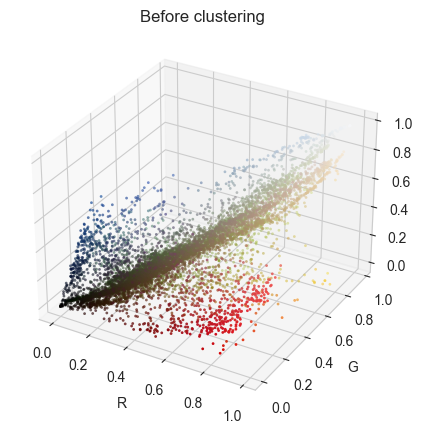

In [8]:
# 3‑D RGB scatter plots (before) --------------------------------
# 전체 픽셀 X 중에서 최대 8000개까지만 샘플링한다.
# 픽셀이 너무 많으면 3D 산점도를 그릴 때 느려질 수 있기 때문에 일부만 뽑는다.
n_sample = min(8000, len(X))

# 전체 픽셀 인덱스 중에서 n_sample개를 무작위로 선택한다.
# replace=False는 같은 인덱스를 중복해서 뽑지 않겠다는 의미이다.
idx      = np.random.choice(len(X), n_sample, replace=False)
Xs       = X[idx]

# 새로운 figure를 생성한다.
# figsize=(12, 5)는 그림의 가로, 세로 크기를 지정한다.
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 1, 1, projection='3d')
ax1.scatter(Xs[:, 0], Xs[:, 1], Xs[:, 2], c=Xs, s=4, edgecolor='none')
# 그래프 제목설정, x축 이름 설정, y축 이름 설정, z축 이름 설정
ax1.set_title('Before clustering'); ax1.set_xlabel('R'); ax1.set_ylabel('G'); ax1.set_zlabel('B');

In [9]:
# fit k‑means --------------------------------------

# 사용할 클러스터의 개수, 즉 색을 16개로 클러스터링 하겠다는 뜻이다.
k = 16  # palette size

# scikit-learn의 KMeans 모델을 생성한다.
# n_clusters=k는 클러스터를 k개 만들겠다는 의미이다.
# init='k-means++'는 초기 중심점을 더 안정적으로 선택하는 방법이다.
kmeans = KMeans(n_clusters=k, init='k-means++')

# X에 대해 k-means를 학습하고, 각 픽셀이 어떤 클러스터에 속하는지 라벨을 반환한다.
# labels의 shape은 (전체 픽셀 수,)이다.
# 예를 들어 labels[i] = 3이면, i번째 픽셀은 3번 클러스터에 속한다는 뜻이다.
labels  = kmeans.fit_predict(X)
# 학습이 끝난 뒤 각 클러스터의 중심점, 즉 대표 RGB 색상을 가져온다.
# palette의 shape은 (k, 3)이다.
# 각 행은 하나의 대표 색상이고, 열은 R, G, B 값을 의미한다.
palette = kmeans.cluster_centers_
print('Training complete')
print(labels)
print(palette)


Training complete
[ 3  3 14 ...  3 12 12]
[[0.7288326  0.17375375 0.1603232 ]
 [0.33314818 0.32764465 0.19829369]
 [0.575331   0.5472899  0.44448608]
 [0.19305643 0.16802783 0.06348091]
 [0.79438424 0.7663827  0.6356155 ]
 [0.51001656 0.511562   0.3178904 ]
 [0.4211366  0.40963605 0.26650137]
 [0.8592663  0.85575545 0.814217  ]
 [0.21153603 0.3109982  0.46943635]
 [0.44039428 0.4167035  0.06764185]
 [0.6495627  0.65194184 0.3979818 ]
 [0.09214699 0.18341604 0.28594738]
 [0.2606151  0.25994146 0.12150161]
 [0.6849158  0.6752757  0.57272243]
 [0.08276871 0.08329257 0.03817046]
 [0.6906592  0.5956359  0.08522464]]


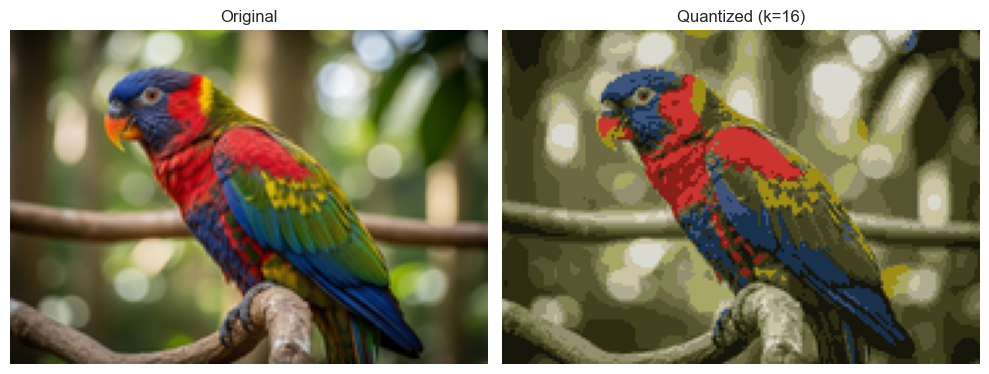

In [34]:
# Reconstruct quantized image ------------------------------------------
# labels에는 각 픽셀이 몇 번 클러스터에 속하는지 저장되어 있다.
# palette에는 각 클러스터의 대표 RGB 색상, 즉 중심점 색상이 저장되어 있다.
# palette[labels]를 하면 각 픽셀을 자기 클러스터의 대표 색상으로 바꾼다.
# reshape(h, w, 3)은 다시 이미지 형태인 (높이, 너비, RGB 3채널)로 복원한다.
# * 255는 0~1 범위의 RGB 값을 다시 0~255 범위로 되돌린다.
# astype(np.uint8)은 이미지 저장/출력에 맞게 정수형 8비트 자료형으로 변환한다.
quant_img = (palette[labels].reshape(h, w, 3) * 255).astype(np.uint8)
# NumPy 배열 quant_img를 PIL Image 객체로 변환한 뒤,
# 'output_k16.jpg'라는 이름으로 저장한다.
Image.fromarray(quant_img).save('output_k16.jpg')

# 원본 이미지와 양자화된 이미지를 나란히 보여주기 위해
# 1행 2열짜리 subplot을 만든다.
# figsize=(10, 4)는 전체 그림 크기를 지정한다.
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img_np);  ax[0].set_title('Original');  ax[0].axis('off')
ax[1].imshow(quant_img); ax[1].set_title(f'Quantized (k={k})'); ax[1].axis('off')
# subplot 사이의 간격을 자동으로 조정해서 겹치지 않게 만든다.
plt.tight_layout()

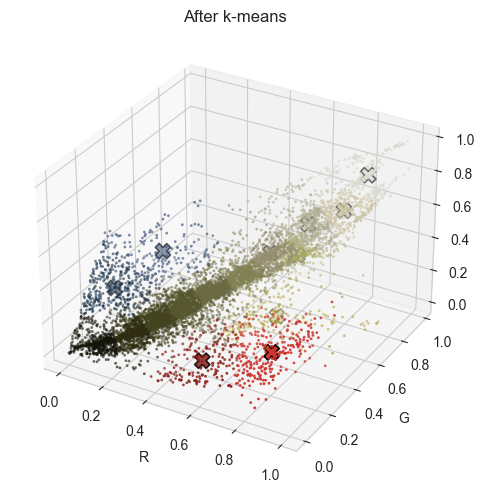

In [35]:
labs = labels[idx]

fig = plt.figure(figsize=(12, 5))
ax2 = fig.add_subplot(1, 1, 1, projection='3d')
ax2.scatter(Xs[:, 0], Xs[:, 1], Xs[:, 2], c=palette[labs], s=4, edgecolor='none')
# k-means가 찾은 중심점, 즉 대표 RGB 색상들을 3D 공간에 표시한다.
# palette[:, 0]은 각 중심점의 R 값,
# palette[:, 1]은 각 중심점의 G 값,
# palette[:, 2]는 각 중심점의 B 값이다.
# c=palette는 중심점 자체의 RGB 색으로 표시하겠다는 의미이다.
# marker='X'는 중심점을 X 모양으로 표시한다.
# s=120은 중심점 마커의 크기이다.
# edgecolor='k'는 검은색 테두리를 의미한다.
# linewidths=1.2는 테두리 두께이다.
# label='centroid'는 범례에 표시할 이름이다.
ax2.scatter(palette[:, 0], palette[:, 1], palette[:, 2],
            c=palette, marker='X', s=120, edgecolor='k', linewidths=1.2, label='centroid')
ax2.set_title('After k-means'); ax2.set_xlabel('R'); ax2.set_ylabel('G'); ax2.set_zlabel('B');

plt.tight_layout()

## 과제: 이미지 양자화를 위한 k-Means 직접 구현

이전 셀에서는 scikit-learn의 `KMeans`를 사용하여 이미지를 양자화했습니다.

이번 과제에서는 **같은 이미지 양자화 문제**를 해결하지만, NumPy를 사용하여 핵심 k-means 알고리즘을 직접 구현해야 합니다.

## 규칙

이 과제 섹션에서는 `sklearn.cluster.KMeans`를 사용하면 안 됩니다.

핵심 알고리즘은 NumPy를 사용하여 구현해야 합니다.

이미지를 불러오고, 재구성하고, 저장하고, 시각화하는 작업에는 PIL과 matplotlib을 사용할 수 있습니다.

모든 `TODO` 블록을 채워야 합니다.

## 구현할 내용

중심점 초기화, 이미지 재구성, 시각화, 팔레트 크기 실험 코드는 제공됩니다.

TODO는 k-means의 핵심 반복 과정에만 초점을 맞춥니다.

1. 픽셀과 중심점 사이의 거리 계산
2. 클러스터 할당
3. 중심점 업데이트
4. 반복적인 k-means 학습

이를 통해 k-means가 데이터 포인트를 클러스터에 반복적으로 할당하고, 클러스터 중심을 업데이트하는 과정을 이해하는 데 집중할 수 있습니다.

[[0.17647059 0.1372549  0.09803922]
 [0.15294118 0.12156863 0.07843137]
 [0.12156863 0.10196078 0.05882353]
 ...
 [0.15294118 0.18431373 0.09019608]
 [0.21176471 0.23921569 0.14509804]
 [0.24705882 0.2745098  0.17647059]]
Image shape: (128, 183, 3)
Pixel data shape: (23424, 3)


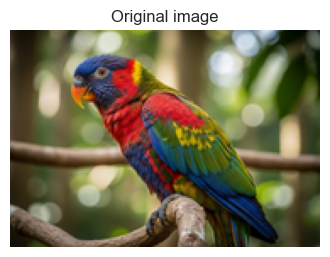

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import io
import requests

IMAGE_URL = 'https://search.pstatic.net/common/?src=http%3A%2F%2Fblogfiles.naver.net%2FMjAyNjAxMjJfNTQg%2FMDAxNzY5MDUzMTU2MDg3.Qp_mFUOmSwfT5s2Ts9KLmLsBY5Kd4gwfDhanu-Ns4uEg.2WX7BIKEXeABk4nDpec_7XqHxSmKbgFmJRFJ3aYPqm0g.JPEG%2F%25BE%25DE%25B9%25AB%25BB%25F5_%25281%2529.jpg&type=sc960_832'

# This assignment reuses the image loaded in the previous section.
# If the previous cells were not executed, this cell downloads the same remote image.
if 'img_np' not in globals():
    response = requests.get(IMAGE_URL, timeout=10)
    response.raise_for_status()
    img = Image.open(io.BytesIO(response.content)).convert('RGB')
    img.thumbnail((256, 128), Image.LANCZOS)
    img_np = np.array(img)

h, w, _ = img_np.shape
X_pixels = img_np.reshape(-1, 3).astype(np.float64) / 255.0
print(X_pixels)
print('Image shape:', img_np.shape)
print('Pixel data shape:', X_pixels.shape)

plt.figure(figsize=(4, 4))
plt.imshow(img_np)
plt.axis('off')
plt.title('Original image')
plt.show()


### Step 1. 중심점 초기화하기 (제공된 코드)

각 중심점은 RGB 색상 벡터입니다.

다음 함수는 이미지에서 `k`개의 픽셀을 무작위로 선택하여 `k`개의 중심점을 초기화합니다.

이 부분은 제공된 코드이므로, 여러분은 k-means의 주요 단계인 거리 계산, 클러스터 할당, 중심점 업데이트에 집중하면 됩니다.

In [37]:
# k-means의 초기 중심점을 생성하는 함수이다.
def initialize_centroids(X, k, random_state=42):

    # 랜덤 시드를 고정한다.
    # 이렇게 하면 코드를 여러 번 실행햐도 같은 픽셀들이 선택된다.
    np.random.seed(random_state)

    # 전체 픽셀 인덱스 중에서 k개를 무작위로 선택한다.
    # replace=False는 같은 픽셀을 중복해서 뽑지 않겠다는 의미이다.
    selected_indices = np.random.choice(len(X), size=k, replace=False)

     # 선택된 픽셀들의 RGB 값을 초기 중심점으로 사용한다.
    # copy()는 원본 X와 독립적인 배열로 복사하기 위해 사용한다
    centroids = X[selected_indices].copy()
    # 초기 중심점 배열을 반환한다.
    return centroids

# Sanity check
centroids_test = initialize_centroids(X_pixels, k=4, random_state=0)
assert centroids_test.shape == (4, 3)
assert np.all(centroids_test >= 0) and np.all(centroids_test <= 1)
print('Initial centroids test passed!')
print(centroids_test) # 4개의 무작위 시작 중심점을 출력


Initial centroids test passed!
[[0.67843137 0.58431373 0.40392157]
 [0.74901961 0.74901961 0.6627451 ]
 [0.32156863 0.37647059 0.54509804]
 [0.42352941 0.30980392 0.18823529]]


### Step 2. 픽셀에서 중심점까지의 거리 계산하기

모든 픽셀에 대해, 각 중심점까지의 **제곱 유클리드 거리**를 계산합니다.

출력 배열의 shape은 다음과 같아야 합니다.

$$
(\text{픽셀 개수}, k)
$$

In [11]:
# review 브로드 캐스팅의 조건
# 오른쪽 차원부터 비교한다.
# 1. 두 차원의 크기가 같다.
# 2. 둘 중 하나가 1이다.
# 3. 한쪽에 해당 차원이 없으면 1로 간주한다.

def compute_squared_distances(X, centroids): # 전체 데이터 : X 와 centroids 의 거리 모두 구하기

    # X[:, None, :]의 shape은 (n_samples, 1, 3)이 된다.
    # centroids[None, :, :]의 shape은 (1, k, 3)이 된다.
    # 두 배열을 빼면 broadcasting에 의해 (n_samples, k, 3)이 된다.
    # 즉, 모든 픽셀과 모든 centroid 사이의 RGB 차이를 한 번에 계산한다.

    #X_reshaped = X.reshape(X.shape[0], 1, X.shape[1])
    #centroids_reshaped = centroids.reshape(1, centroids.shape[0], centroids.shape[1])

    #diff = X_reshaped - centroids_reshaped  reshape 으로도 가능하다.

    diff = X[:, None, :] - centroids[None, :, :]

    # diff ** 2는 RGB 차이를 제곱한다.
    # axis=2는 R, G, B 세 채널 방향으로 더하겠다는 뜻이다.
    # 결과 shape은 (n_samples, k)가 된다.
    distances = np.sum(diff ** 2, axis=2)

    # 각 픽셀과 각 centroid 사이의 제곱 유클리드 거리 행렬을 반환한다.
    return distances


# Sanity check with small artificial data
X_small = np.array([[0, 0, 0], [1, 1, 1]], dtype=float)
C_small = np.array([[0, 0, 0], [1, 0, 0]], dtype=float)
D_small = compute_squared_distances(X_small, C_small)
assert D_small.shape == (2, 2)
assert np.allclose(D_small, np.array([[0, 1], [3, 2]], dtype=float))
print('Distance calculation test passed!')
D = compute_squared_distances(X_pixels, centroids_test)
print(D)
print(np.shape(D))


Distance calculation test passed!


NameError: name 'X_pixels' is not defined


### Step 3. 각 픽셀을 가장 가까운 중심점에 배정하기


In [10]:
def assign_clusters(X, centroids):

    # 모든 픽셀과 모든 centroid 사이의 제곱 유클리드 거리를 계산한다.
    # distances의 shape은 (n_samples, k)이다.
    # 각 행은 픽셀 하나, 각 열은 centroid 하나와의 거리이다.
    distances = compute_squared_distances(X, centroids)

    # 각 픽셀마다 가장 가까운 centroid의 인덱스를 찾는다.
    # axis=1은 각 행마다 최솟값의 위치를 찾겠다는 뜻이다.
    # labels의 shape은 (n_samples,)가 된다.
    labels = np.argmin(distances, axis=1) #

    # 각 픽셀이 몇 번 centroid에 속하는지 반환한다.
    return labels


labels_test = assign_clusters(X_small, C_small)

assert labels_test.shape == (2,)
assert np.array_equal(labels_test, np.array([0, 1]))
print(assign_clusters(X_pixels, centroids_test))
print('Cluster assignment test passed!')

NameError: name 'X_small' is not defined

### Step 4. 중심점 업데이트하기

각 클러스터마다, 그 클러스터에 할당된 모든 픽셀들의 RGB 값 평균을 계산합니다.

이번 과제에서는 모든 클러스터에 적어도 하나 이상의 픽셀이 할당되어 있다고 가정합니다.

이렇게 하면 구현을 k-means의 핵심 아이디어에 집중할 수 있습니다.
즉, 각 클러스터에 속한 데이터들의 평균을 구해서 해당 클러스터의 중심점을 새롭게 업데이트하는 과정에 집중할 수 있습니다.

In [40]:
def update_centroids(X, labels, k):

    # 새로운 centroid들을 저장할 배열을 만든다.
    # shape은 (k, X.shape[1])이다.
    # 이미지 RGB 데이터라면 X.shape[1]은 3이므로, 결과 shape은 (k, 3)이 된다.
    new_centroids = np.zeros((k, X.shape[1]), dtype=X.dtype)

    # 각 클러스터 번호 j에 대해 반복한다.
    # k=2이면 j는 0, 1
    # k=4이면 j는 0, 1, 2, 3
    for j in range(k):

        # labels == j는 j번 클러스터에 속한 픽셀만 True가 되는 boolean 배열이다.
        # X[labels == j]는 j번 클러스터에 속한 픽셀들만 가져온다.
        assigned_pixels = X[labels == j]

        # j번 클러스터에 속한 픽셀들의 RGB 평균을 계산한다.
        # axis=0은 각 컬럼별 평균, 즉 R 평균, G 평균, B 평균을 구한다는 뜻이다.
        new_centroids[j] = assigned_pixels.mean(axis=0)

    # 새롭게 계산된 centroid 배열을 반환한다.
    return new_centroids


updated_test = update_centroids(X_small, labels_test, k=2)

assert updated_test.shape == (2, 3) # 2 centroids with 3 color channels
print('Centroid update test passed!')

Centroid update test passed!


### Step 5. k-means 학습하기

다음 과정을 반복합니다.

1. 각 픽셀을 가장 가까운 중심점에 할당합니다.
2. 각 중심점을 해당 중심점에 할당된 픽셀들의 평균 색상으로 업데이트합니다.
3. 중심점들이 거의 움직이지 않으면 반복을 멈춥니다.

속도를 높이기 위해, 아래 코드는 전체 픽셀을 모두 사용하지 않고 무작위로 뽑은 일부 픽셀로 중심점을 학습한 뒤, 학습된 중심점을 전체 이미지에 적용합니다.

In [42]:
def kmeans_from_scratch(X, k, max_iter=30, tol=1e-4, random_state=42):

    # 초기 centroid를 랜덤하게 선택한다.
    # centroids의 shape은 (k, 3)이다.
    centroids = initialize_centroids(X, k, random_state=random_state)

    # 최대 max_iter번까지 k-means 반복을 수행한다.
    for it in range(max_iter):

        # 현재 centroid를 기준으로 각 픽셀을 가장 가까운 클러스터에 배정한다.
        # labels의 shape은 (n_samples,)이다.
        labels = assign_clusters(X, centroids)

        # centroid가 얼마나 움직였는지 계산하기 위해
        # 업데이트 전 centroid를 따로 저장해 둔다.
        old_centroids = centroids.copy()

        # 각 클러스터에 속한 픽셀들의 평균 RGB 값으로 centroid를 업데이트한다.
        centroids = update_centroids(X, labels, k)

        # 이전 centroid와 새 centroid 사이의 이동 거리를 계산한다.
        # old_centroids - centroids의 shape은 (k, 3)이다.
        # axis=1 기준으로 L2 norm을 계산하면 각 centroid별 이동 거리가 나온다.
        centroid_shift = np.linalg.norm(old_centroids - centroids, axis=1)

        # 모든 centroid 중 가장 많이 움직인 거리도 tol보다 작으면 학습을 멈춘다.
        # 즉, 중심점들이 거의 변하지 않으면 수렴했다고 판단한다.
        if np.max(centroid_shift) < tol:
            break

    # it은 0부터 시작하므로 실제 반복 횟수는 it + 1이다.
    return centroids, labels, it + 1


# Train on the full image using all pixels.
X_train_pixels = X_pixels

k = 16
centroids, train_labels, n_iter = kmeans_from_scratch(
    X_train_pixels, k=k, max_iter=30, tol=1e-4, random_state=42
)

print('Centroids shape:', centroids.shape)
print('Number of iterations:', n_iter)

Centroids shape: (16, 3)
Number of iterations: 30


### Step 6. 양자화된 이미지 재구성하기

k-means 알고리즘 자체는 이전 단계들에서 이미 구현되었습니다.

아래 셀은 제공된 코드입니다.
이 코드는 학습된 중심점들을 색상 팔레트로 사용하고, 모든 픽셀을 가장 가까운 중심점 색상으로 교체합니다.

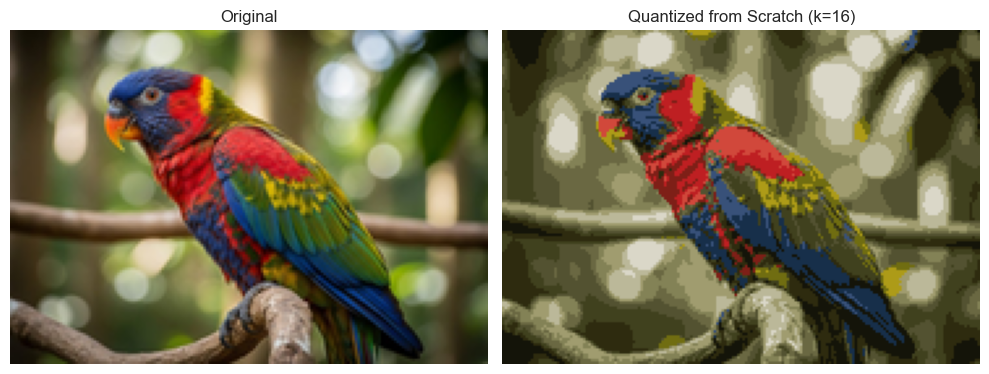

Saved: output_from_scratch_k16.jpg


In [45]:
# Provided code: reconstruct quantized image ----------------------------

# 전체 이미지의 모든 픽셀을 가장 가까운 학습된 centroid에 할당한다.
# X_pixels는 원본 이미지의 모든 픽셀 RGB 값이다.
# centroids는 k-means 학습으로 얻은 대표 색상들이다.
# full_labels의 shape은 (전체 픽셀 수,)이다.
full_labels = assign_clusters(X_pixels, centroids)

# 각 픽셀을 자신이 속한 클러스터의 centroid 색상으로 교체한다.
# centroids[full_labels]는 각 픽셀의 label에 해당하는 대표 RGB 색상을 가져온다.
# 예를 들어 full_labels[0] = 3이면, 0번째 픽셀은 centroids[3] 색상으로 바뀐다.
quantized_pixels = centroids[full_labels]

# 1차원 픽셀 배열을 다시 원본 이미지 shape으로 복원한다.
# quantized_pixels의 shape은 (전체 픽셀 수, 3)이다.
# img_np.shape은 원본 이미지의 shape, 즉 (height, width, 3)이다.
# * 255는 0~1 범위의 RGB 값을 다시 0~255 범위로 되돌린다.
# clip(0, 255)는 혹시 범위를 벗어난 값이 있으면 0~255 안으로 제한한다.
# astype(np.uint8)은 이미지 출력/저장에 적합한 8비트 정수형으로 변환한다.
quantized_img = (quantized_pixels.reshape(img_np.shape) * 255).clip(0, 255).astype(np.uint8)

# 양자화된 이미지의 shape이 원본 이미지와 같은지 확인한다.
# 이미지로 출력하려면 높이, 너비, RGB 채널 수가 원본과 같아야 한다.
assert quantized_img.shape == img_np.shape

# 원본 이미지와 양자화된 이미지를 나란히 출력하기 위한 figure를 만든다.
# figsize=(10, 4)는 전체 그림의 가로, 세로 크기이다.
plt.figure(figsize=(10, 4))

# 1행 2열 중 첫 번째 위치에 그래프를 만든다.
plt.subplot(1, 2, 1)

# 원본 이미지를 출력한다.
plt.imshow(img_np)

# 축 눈금과 테두리를 숨긴다.
plt.axis('off')

# 첫 번째 이미지의 제목을 설정한다.
plt.title('Original')

# 1행 2열 중 두 번째 위치에 그래프를 만든다.
plt.subplot(1, 2, 2)

# k-means from scratch로 양자화한 이미지를 출력한다.
plt.imshow(quantized_img)

# 축 눈금과 테두리를 숨긴다.
plt.axis('off')

# 두 번째 이미지의 제목을 설정한다.
# k는 사용한 대표 색상 개수, 즉 클러스터 개수이다.
plt.title(f'Quantized from Scratch (k={k})')

# subplot 사이의 간격을 자동으로 조정한다.
plt.tight_layout()

# 화면에 이미지를 출력한다.
plt.show()

# NumPy 배열 quantized_img를 PIL Image 객체로 변환한 뒤 jpg 파일로 저장한다.
# 파일 이름은 k값에 따라 output_from_scratch_k16.jpg 같은 형식이 된다.
Image.fromarray(quantized_img).save(f'output_from_scratch_k{k}.jpg')

# 저장된 파일 이름을 출력한다.
print(f'Saved: output_from_scratch_k{k}.jpg')

### Step 7. 학습 진행 상황

k-means 알고리즘이 완료되기까지 걸리는 반복 횟수는 보통 작은 편이어야 합니다.

In [47]:

# Provided code: training progress -------------------------------
print(f"Training completed in {n_iter} iterations.")


Training completed in 30 iterations.


### Step 8. 서로 다른 팔레트 크기로 실험하기

아래 셀은 제공된 코드입니다.
이 코드는 여러분이 구현한 k-means를 여러 `k` 값에 대해 실행하고, 그 결과로 만들어진 양자화 이미지를 시각화합니다.

`k = 4, 8, 16, 32`를 시도한 뒤, 아래 질문에 답하세요.

1. `k`가 증가할수록 이미지 품질은 어떻게 변하나요?
2. 양자화된 이미지에서 색상의 개수는 어떻게 변하나요?
3. 이미지 품질과 색상 수 감소 사이에서 가장 적절한 균형을 주는 `k` 값은 무엇인가요?
4. k-means가 이미지 양자화에 유용한 이유는 무엇인가요?

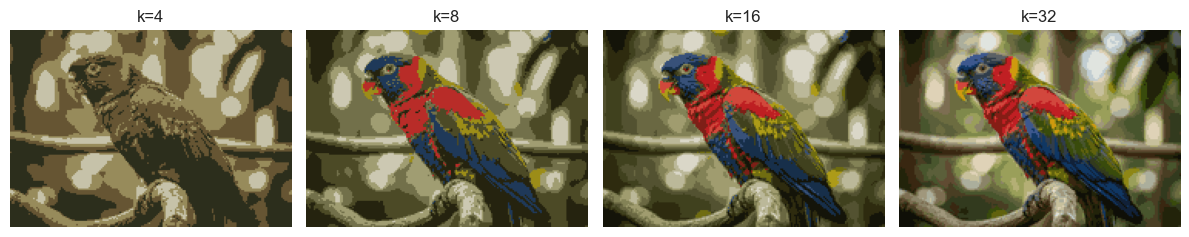

In [50]:
# Provided code: palette-size experiment -------------------------------
k_values = [4, 8, 16, 32]
quantized_results = []

for k_exp in k_values:
    centroids_exp, _, _ = kmeans_from_scratch(
        X_pixels, k=k_exp, max_iter=30, tol=1e-4, random_state=42
    )
    labels_exp = assign_clusters(X_pixels, centroids_exp)
    quantized_pixels_exp = centroids_exp[labels_exp]
    quantized_img_exp = (
        quantized_pixels_exp.reshape(img_np.shape) * 255
    ).clip(0, 255).astype(np.uint8)
    quantized_results.append(quantized_img_exp)

# Visualization
plt.figure(figsize=(12, 4))
for i, (k_exp, img_q) in enumerate(zip(k_values, quantized_results)):
    plt.subplot(1, len(k_values), i + 1)
    plt.imshow(img_q)
    plt.axis('off')
    plt.title(f'k={k_exp}')
plt.tight_layout()
plt.show()
